# Reto 2 · Modelo EBM: ¿qué fenotipo tendrá el paciente a los 3 meses?

**Notebook 06.** Con los datos disponibles **el día del alta**, predice a qué fenotipo funcional pertenecerá el paciente a los 3 meses:
- **F1 · función conservada**
- **F2 · afectación funcional** (DLCO ≈ 65 %, FVC ≈ 73 %)

Es el clustering H3 del notebook 05, común a CIBERESUCICOVID, POSTCOVID-Lleida y TENACITY.

| | |
|---|---|
| Diana | `fenotipo_H3` = F2 (afectación funcional) frente a F1 |
| Predictores | Datos del alta **comunes a las tres cohortes**: edad, sexo, días de estancia, ingreso en UCI, hipertensión, diabetes, cardiopatía, EPOC, enfermedad renal y tabaquismo |
| Modelo | **Explainable Boosting Machine** (EBM, librería `interpret`): un modelo aditivo, `riesgo = Σ f(variable) + interacciones`, en el que cada variable tiene una curva que se puede mirar. Es tan interpretable como una regresión logística, pero capta relaciones no lineales |
| Partición | **80 % entrenamiento / 20 % test**, estratificada por diana y cohorte. Además, como robustez, **validación dejando fuera cada cohorte** (§7) |
| Comparación | Regresión logística con los mismos predictores, como referencia |
| Sin fuga | Los predictores son del alta; la diana se mide a los 3 meses con DLCO, FVC y FEV1, que **no** son predictores |

> **Privacidad.** Solo agregados. El modelo y el dataset se guardan en `Datos limpios/`, fuera del repositorio.

## 0 · Entorno

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix, f1_score,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, privacidad

cfg = carga.cargar_config()
MC = cfg["modelo_h3"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)
PFX = "06_ebm"
C_EBM, C_LOG = "#6a3d9a", "#999999"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)

NOMBRES = {"edad": "Edad", "estancia_hosp_dias": "Estancia (días)", "sexo": "Sexo (mujer)", "nu_ingreso_uci": "UCI",
           "nu_hta": "HTA", "nu_diabetes": "Diabetes", "nu_card_cronica": "Cardiopatía", "nu_epoc": "EPOC",
           "nu_renal_cronica": "Enf. renal", "nu_tabaquismo": "Tabaquismo"}


def nota(fig, texto: str) -> None:
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def edad_aproximada(tramo) -> float:
    """Punto medio del tramo de edad ('60-64' -> 62; '70+' -> 72; '<50' -> NaN por ser demasiado amplio)."""
    if not isinstance(tramo, str) or tramo.startswith("<"):
        return np.nan
    if tramo.endswith("+"):
        return float(tramo[:-1]) + 2
    lo, hi = tramo.split("-")
    return (float(lo) + float(hi)) / 2


def ic_bootstrap(y: np.ndarray, p: np.ndarray, metrica, n: int, semilla: int) -> tuple[float, float]:
    """IC 95 % bootstrap (percentiles) de una métrica sobre (y, p)."""
    rng = np.random.default_rng(semilla)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            vals.append(metrica(y[idx], p[idx]))
    return tuple(np.percentile(vals, [2.5, 97.5]))

## 1 · Dataset

In [2]:
base = pd.read_parquet(DATOS / MC["base"])
pacientes = pd.read_parquet(DATOS / "pacientes.parquet").set_index("subject_id")
d = base[base[MC["diana"]].notna()].set_index("subject_id").copy()
d["edad"] = pacientes.loc[d.index, "edad_tramo5"].map(edad_aproximada)
d["y"] = (d[MC["diana"]] == MC["clase_positiva"]).astype(int)

CONT, BIN, CAT = MC["predictores"]["continuas"], MC["predictores"]["binarias"], MC["predictores"]["categoricas"]
FEATS = CONT + BIN + CAT
dataset = d[["cohorte_analisis", "centro_id", *FEATS, MC["diana"], "y"]]
dataset.reset_index().to_parquet(DATOS / "dataset_modelo_h3.parquet", index=False)
print(f"Dataset: {len(dataset):,} pacientes × {len(FEATS)} predictores; guardado en {DATOS.name}/dataset_modelo_h3.parquet")
print(f"Clase positiva (F2, afectación funcional): {dataset['y'].mean():.1%}")
privacidad.suprimir_celdas(pd.crosstab(dataset["cohorte_analisis"].astype(str).map(ETQ), dataset[MC["diana"]], margins=True,
                                       margins_name="Total"), N_MIN, ["F1", "F2", "Total"])

Dataset: 1,574 pacientes × 10 predictores; guardado en Datos limpios/dataset_modelo_h3.parquet
Clase positiva (F2, afectación funcional): 47.8%


fenotipo_H3,F1,F2,Total
cohorte_analisis,,,
CIBERESUCICOVID,543,413,956
POSTCOVID-Lleida,205,259,464
TENACITY,73,81,154
Total,821,753,1574


In [3]:
# Descripción de los predictores por clase (solo agregados)
filas = {}
for clase, g in dataset.groupby(MC["diana"]):
    col = {"N": len(g), "Edad (mediana)": g["edad"].median(), "Estancia (mediana, días)": g["estancia_hosp_dias"].median()}
    for v in BIN:
        col[f"{NOMBRES[v]} (%)"] = 100 * g[v].mean()
    for cod, etq in [(1, "Fumador activo"), (2, "Exfumador")]:
        col[f"{etq} (%)"] = 100 * (g["nu_tabaquismo"] == cod).sum() / g["nu_tabaquismo"].notna().sum()
    col["% con algún dato ausente"] = 100 * g[FEATS].isna().any(axis=1).mean()
    filas[clase] = col
pd.DataFrame(filas).round(1)

,F1,F2
N,821.0,753.0
Edad (mediana),62.0,62.0
"Estancia (mediana, días)",21.0,26.0
Sexo (mujer) (%),33.9,25.6
UCI (%),94.9,91.6
HTA (%),39.7,49.5
Diabetes (%),14.8,22.0
Cardiopatía (%),8.9,10.6
EPOC (%),3.6,8.6
Enf. renal (%),2.7,6.4


## 2 · Partición 80 / 20

In [4]:
estrato = dataset["y"].astype(str) + "_" + dataset["cohorte_analisis"].astype(str)
train, test = train_test_split(dataset, test_size=MC["test_size"], stratify=estrato, random_state=SEMILLA)
X_tr, y_tr, X_te, y_te = train[FEATS], train["y"].to_numpy(), test[FEATS], test["y"].to_numpy()
reparto = pd.DataFrame({"train": train["cohorte_analisis"].astype(str).value_counts(),
                        "test": test["cohorte_analisis"].astype(str).value_counts()}).rename(index=ETQ)
reparto.loc["Total"] = reparto.sum()
reparto.loc["% F2"] = [round(100 * y_tr.mean(), 1), round(100 * y_te.mean(), 1)]
reparto

,train,test
cohorte_analisis,,
CIBERESUCICOVID,764.0,192.0
POSTCOVID-Lleida,371.0,93.0
TENACITY,124.0,30.0
Total,1259.0,315.0
% F2,47.8,47.9


## 3 · Entrenamiento: EBM y regresión logística de referencia

In [5]:
tipos = ["continuous"] * len(CONT) + ["nominal"] * (len(BIN) + len(CAT))
ebm = ExplainableBoostingClassifier(feature_names=[NOMBRES[f] for f in FEATS], feature_types=tipos,
                                    interactions=MC["ebm"]["interactions"], outer_bags=MC["ebm"]["outer_bags"],
                                    learning_rate=MC["ebm"]["learning_rate"], max_rounds=MC["ebm"]["max_rounds"],
                                    random_state=SEMILLA)
ebm.fit(X_tr, y_tr)

logit = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler())]), CONT + BIN),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), CAT)])),
    ("lr", LogisticRegression(max_iter=2000))])
logit.fit(X_tr, y_tr)

p_ebm, p_log = ebm.predict_proba(X_te)[:, 1], logit.predict_proba(X_te)[:, 1]
print(f"EBM entrenado: {len(ebm.term_names_)} términos ({len(FEATS)} efectos principales + "
      f"{len(ebm.term_names_) - len(FEATS)} interacciones)")

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

EBM entrenado: 15 términos (10 efectos principales + 5 interacciones)


C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(


## 4 · Rendimiento en test

In [6]:
def metricas(y, p, umbral):
    pred = (p >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"ROC-AUC": roc_auc_score(y, p), "PR-AUC (AP)": average_precision_score(y, p), "Brier": brier_score_loss(y, p),
            "Sensibilidad": tp / (tp + fn), "Especificidad": tn / (tn + fp), "VPP": tp / max(tp + fp, 1),
            "Exactitud": (tp + tn) / len(y), "F1": f1_score(y, pred)}


# Umbral de Youden elegido con validación cruzada en TRAIN (no en test, para no ser optimistas)
p_oof = cross_val_predict(ExplainableBoostingClassifier(**{k: v for k, v in ebm.get_params().items()}), X_tr, y_tr,
                          cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA), method="predict_proba")[:, 1]
fpr, tpr, thr = roc_curve(y_tr, p_oof)
UMBRAL_YOUDEN = float(thr[np.argmax(tpr - fpr)])
print(f"Umbral de Youden (validación cruzada en train): {UMBRAL_YOUDEN:.3f}; AUC de validación cruzada en train: "
      f"{roc_auc_score(y_tr, p_oof):.3f}")

filas = {}
for nombre, p in [("EBM", p_ebm), ("Logística", p_log)]:
    for etq, u in [("umbral 0,5", 0.5), ("umbral Youden", UMBRAL_YOUDEN)]:
        filas[f"{nombre} · {etq}"] = metricas(y_te, p, u)
tabla_met = pd.DataFrame(filas).T.round(3)
for nombre, p in [("EBM", p_ebm), ("Logística", p_log)]:
    lo, hi = ic_bootstrap(y_te, p, roc_auc_score, MC["n_bootstrap_ic"], SEMILLA)
    tabla_met.loc[[i for i in tabla_met.index if i.startswith(nombre)], "ROC-AUC IC95"] = f"{lo:.3f}–{hi:.3f}"
tabla_met.to_csv(TAB / f"{PFX}_metricas_test.csv")
print(f"Test: N = {len(y_te)}, prevalencia de F2 = {y_te.mean():.1%}")
tabla_met

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

Umbral de Youden (validación cruzada en train): 0.474; AUC de validación cruzada en train: 0.622


Test: N = 315, prevalencia de F2 = 47.9%


,ROC-AUC,PR-AUC (AP),Brier,Sensibilidad,Especificidad,VPP,Exactitud,F1,ROC-AUC IC95
"EBM · umbral 0,5",0.634,0.616,0.236,0.477,0.701,0.595,0.594,0.529,0.574–0.696
EBM · umbral Youden,0.634,0.616,0.236,0.556,0.652,0.596,0.606,0.575,0.574–0.696
"Logística · umbral 0,5",0.633,0.609,0.238,0.477,0.689,0.585,0.587,0.526,0.571–0.698
Logística · umbral Youden,0.633,0.609,0.238,0.576,0.634,0.592,0.606,0.584,0.571–0.698


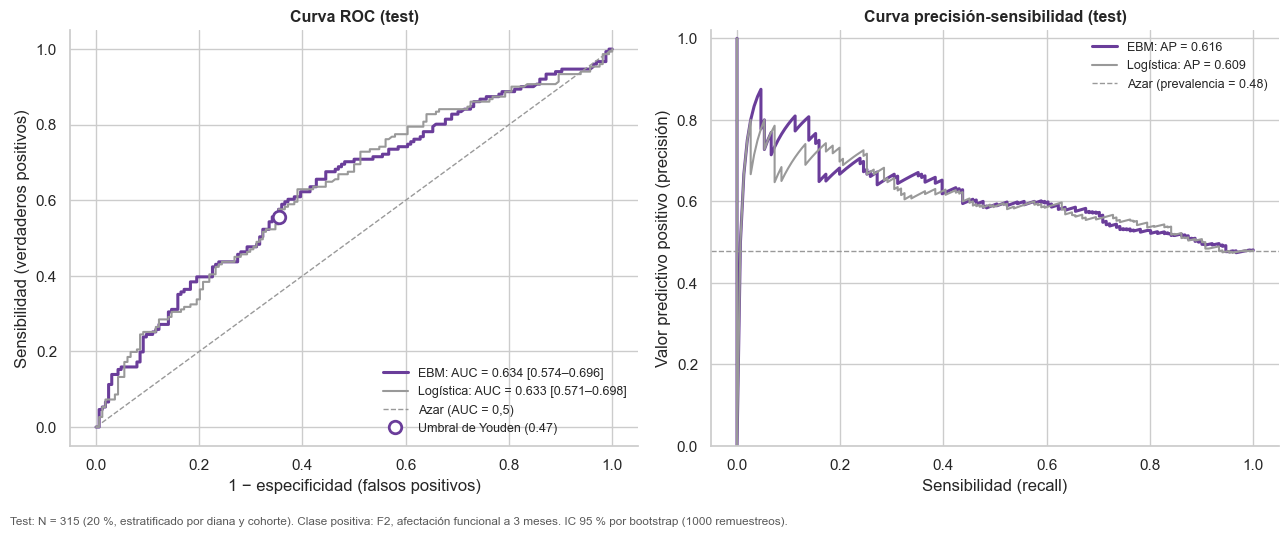

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
for nombre, p, color in [("EBM", p_ebm, C_EBM), ("Logística", p_log, C_LOG)]:
    f, t, _ = roc_curve(y_te, p)
    lo, hi = ic_bootstrap(y_te, p, roc_auc_score, MC["n_bootstrap_ic"], SEMILLA)
    ax.plot(f, t, color=color, lw=2.2 if nombre == "EBM" else 1.5,
            label=f"{nombre}: AUC = {roc_auc_score(y_te, p):.3f} [{lo:.3f}–{hi:.3f}]")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1, label="Azar (AUC = 0,5)")
f, t, _ = roc_curve(y_te, p_ebm)
j = np.argmin(np.abs(roc_curve(y_te, p_ebm)[2] - UMBRAL_YOUDEN))
ax.plot(f[j], t[j], "o", color=C_EBM, ms=9, mfc="white", mew=2, label=f"Umbral de Youden ({UMBRAL_YOUDEN:.2f})")
ax.set_xlabel("1 − especificidad (falsos positivos)"); ax.set_ylabel("Sensibilidad (verdaderos positivos)")
ax.set_title("Curva ROC (test)"); ax.legend(frameon=False, fontsize=9, loc="lower right")

ax = axes[1]
for nombre, p, color in [("EBM", p_ebm, C_EBM), ("Logística", p_log, C_LOG)]:
    pr, rc, _ = precision_recall_curve(y_te, p)
    ax.plot(rc, pr, color=color, lw=2.2 if nombre == "EBM" else 1.5, label=f"{nombre}: AP = {average_precision_score(y_te, p):.3f}")
ax.axhline(y_te.mean(), ls="--", color="0.6", lw=1, label=f"Azar (prevalencia = {y_te.mean():.2f})")
ax.set_xlabel("Sensibilidad (recall)"); ax.set_ylabel("Valor predictivo positivo (precisión)")
ax.set_title("Curva precisión-sensibilidad (test)"); ax.legend(frameon=False, fontsize=9); ax.set_ylim(0, 1.02)
nota(fig, f"Test: N = {len(y_te)} (20 %, estratificado por diana y cohorte). Clase positiva: F2, afectación funcional a 3 meses. "
          f"IC 95 % por bootstrap ({MC['n_bootstrap_ic']} remuestreos).")
plt.tight_layout(); guardar(fig, "roc_pr"); plt.show()

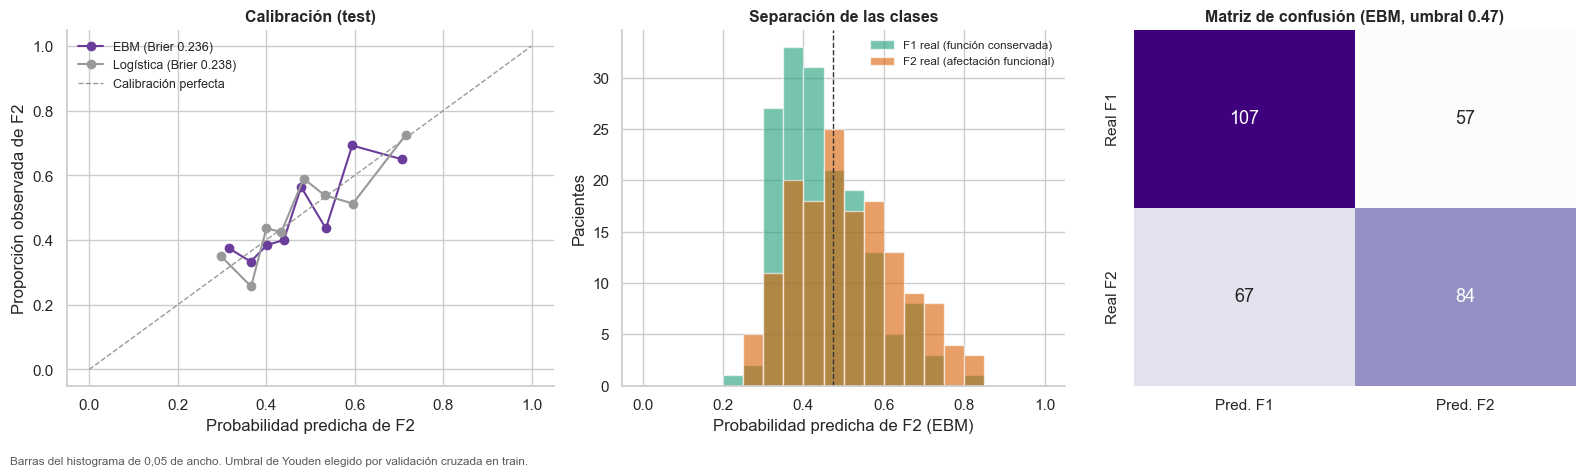

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.1, 1, 1]})
ax = axes[0]
for nombre, p, color in [("EBM", p_ebm, C_EBM), ("Logística", p_log, C_LOG)]:
    fr, mp = calibration_curve(y_te, p, n_bins=MC["n_bins_calibracion"], strategy="quantile")
    ax.plot(mp, fr, "o-", color=color, label=f"{nombre} (Brier {brier_score_loss(y_te, p):.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1, label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha de F2"); ax.set_ylabel("Proporción observada de F2")
ax.set_title("Calibración (test)"); ax.legend(frameon=False, fontsize=9)

ax = axes[1]
bins = np.linspace(0, 1, 21)
ax.hist(p_ebm[y_te == 0], bins=bins, alpha=0.6, color="#1b9e77", label="F1 real (función conservada)")
ax.hist(p_ebm[y_te == 1], bins=bins, alpha=0.6, color="#d95f02", label="F2 real (afectación funcional)")
ax.axvline(UMBRAL_YOUDEN, color="0.2", ls="--", lw=1)
ax.set_xlabel("Probabilidad predicha de F2 (EBM)"); ax.set_ylabel("Pacientes"); ax.set_title("Separación de las clases")
ax.legend(frameon=False, fontsize=8.5)

ax = axes[2]
cm = confusion_matrix(y_te, (p_ebm >= UMBRAL_YOUDEN).astype(int), labels=[0, 1])
anot = np.where(cm < N_MIN, "<10", cm.astype(str))
sns.heatmap(cm, annot=anot, fmt="", cmap="Purples", cbar=False, ax=ax,
            xticklabels=["Pred. F1", "Pred. F2"], yticklabels=["Real F1", "Real F2"], annot_kws={"size": 13})
ax.set_title(f"Matriz de confusión (EBM, umbral {UMBRAL_YOUDEN:.2f})")
nota(fig, "Barras del histograma de 0,05 de ancho. Umbral de Youden elegido por validación cruzada en train.")
plt.tight_layout(); guardar(fig, "calibracion_confusion"); plt.show()

## 5 · Interpretación del EBM

### 5.1 Importancia global
La importancia de cada término es la **contribución media absoluta al log-odds** en los datos de entrenamiento: cuánto mueve, de media, la predicción de un paciente.

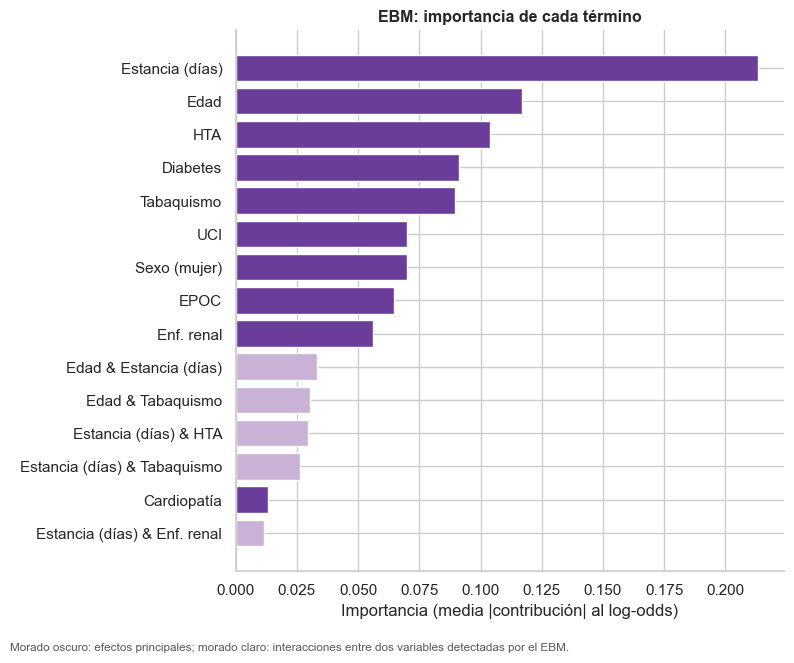

In [9]:
imp = pd.Series(ebm.term_importances(), index=ebm.term_names_).sort_values()
fig, ax = plt.subplots(figsize=(8, 0.35 * len(imp) + 1.2))
colores = [C_EBM if " & " not in t else "#cab2d6" for t in imp.index]
ax.barh(imp.index, imp.values, color=colores)
ax.set_xlabel("Importancia (media |contribución| al log-odds)"); ax.set_title("EBM: importancia de cada término")
nota(fig, "Morado oscuro: efectos principales; morado claro: interacciones entre dos variables detectadas por el EBM.")
plt.tight_layout(); guardar(fig, "importancia"); plt.show()
imp.sort_values(ascending=False).round(3).to_frame("importancia").to_csv(TAB / f"{PFX}_importancia.csv")

### 5.2 Funciones de forma: cómo cambia el riesgo con cada variable

En cada gráfico, el eje Y es la **contribución al log-odds de F2**:
- **> 0** aumenta la probabilidad de afectación funcional a los 3 meses.
- **< 0** la reduce.

La banda es la incertidumbre entre las bolsas (*bags*) del modelo.

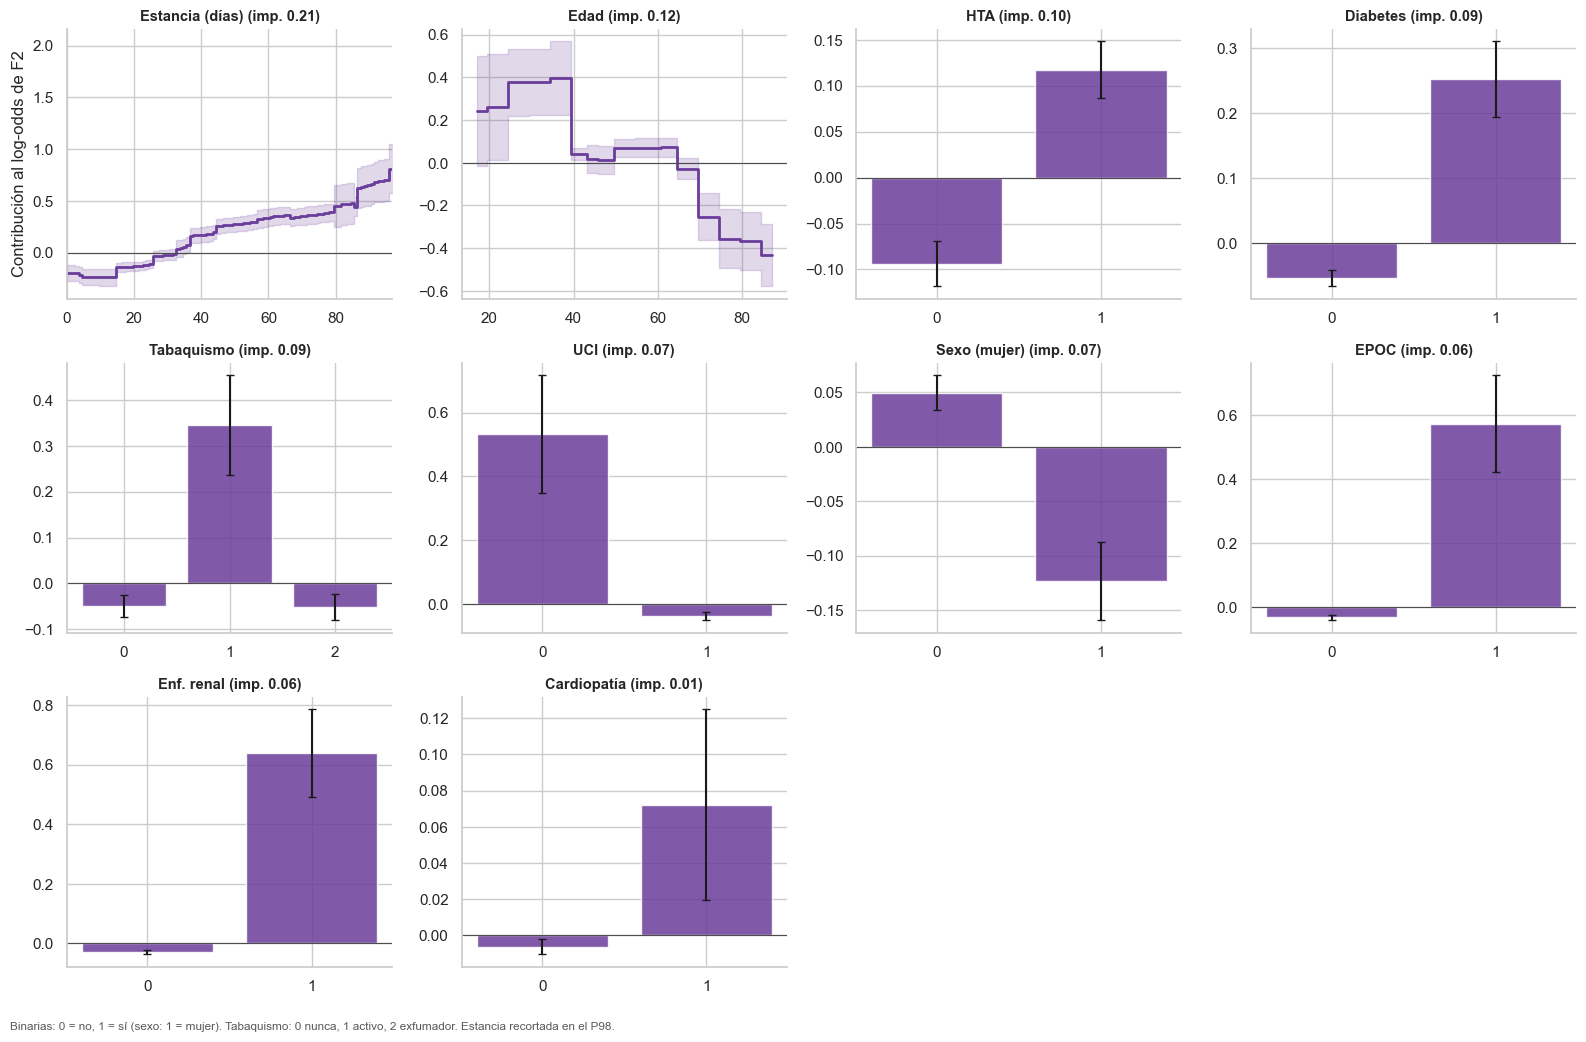

In [10]:
glob = ebm.explain_global()
principales = [i for i, t in enumerate(ebm.term_names_) if " & " not in t]
orden = sorted(principales, key=lambda i: -ebm.term_importances()[i])
n = len(orden); ncol = 4; nfil = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nfil, ncol, figsize=(16, 3.4 * nfil))
for ax, i in zip(axes.flat, orden):
    dat = glob.data(i)
    nombre = ebm.term_names_[i]
    sc, lo, hi = np.array(dat["scores"]), np.array(dat["lower_bounds"]), np.array(dat["upper_bounds"])
    if ebm.feature_types_in_[i] == "continuous":
        bordes = np.array(dat["names"], float)
        ax.step(bordes, np.r_[sc, sc[-1]], where="post", color=C_EBM, lw=2)
        ax.fill_between(bordes, np.r_[lo, lo[-1]], np.r_[hi, hi[-1]], step="post", color=C_EBM, alpha=0.2)
        if nombre.startswith("Estancia"):
            ax.set_xlim(0, np.percentile(dataset["estancia_hosp_dias"].dropna(), 98))
    else:
        etiquetas = [str(x).replace(".0", "") for x in dat["names"]]
        ax.bar(range(len(sc)), sc, color=C_EBM, alpha=0.85, yerr=[sc - lo, hi - sc], capsize=3)
        ax.set_xticks(range(len(sc)), etiquetas)
    ax.axhline(0, color="0.3", lw=0.8)
    ax.set_title(f"{nombre} (imp. {ebm.term_importances()[i]:.2f})", fontsize=10.5)
for ax in list(axes.flat)[n:]:
    ax.axis("off")
axes.flat[0].set_ylabel("Contribución al log-odds de F2")
nota(fig, "Binarias: 0 = no, 1 = sí (sexo: 1 = mujer). Tabaquismo: 0 nunca, 1 activo, 2 exfumador. Estancia recortada en el P98.")
plt.tight_layout(); guardar(fig, "formas"); plt.show()

In [11]:
inter = [t for t in ebm.term_names_ if " & " in t]
print("Interacciones incluidas por el EBM:", inter if inter else "ninguna")

Interacciones incluidas por el EBM: ['Edad & Estancia (días)', 'Edad & Tabaquismo', 'Estancia (días) & HTA', 'Estancia (días) & Enf. renal', 'Estancia (días) & Tabaquismo']


### 5.3 Explicación de pacientes concretos (local)

Para tres pacientes **ficticios de ejemplo** (no reales), cómo suma cada variable hasta la predicción. Es lo que vería el médico en consulta.

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(


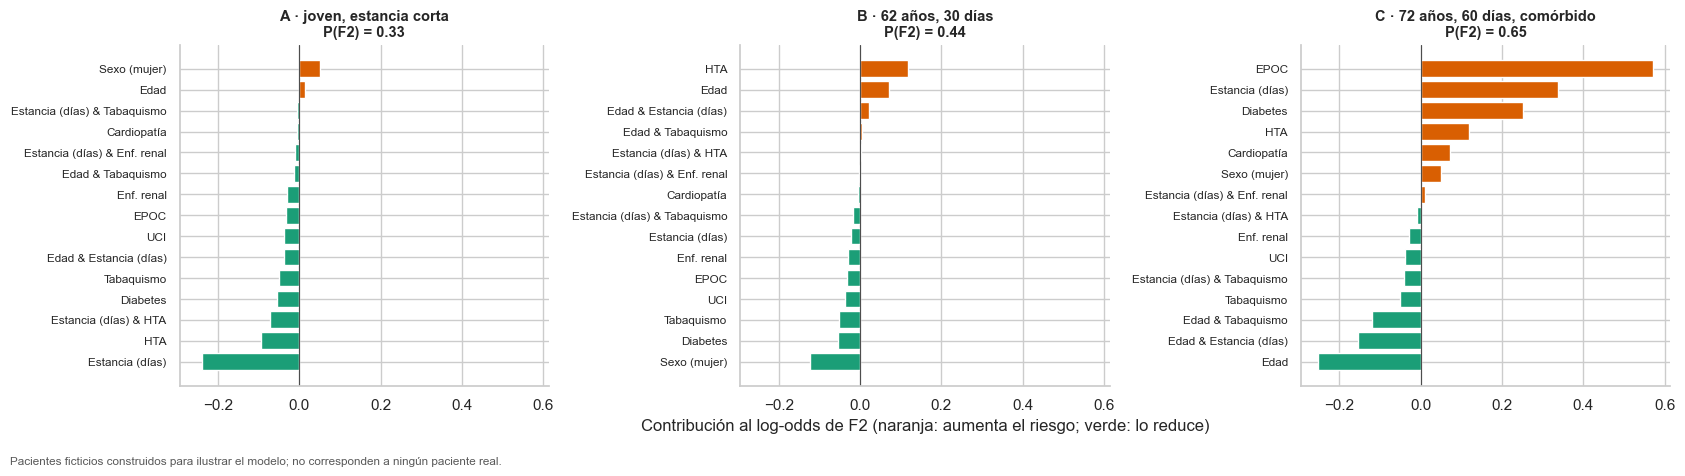

In [12]:
ejemplos = pd.DataFrame([
    {"edad": 47, "estancia_hosp_dias": 10, "sexo": 0, "nu_ingreso_uci": 1, "nu_hta": 0, "nu_diabetes": 0,
     "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "nu_tabaquismo": 0},
    {"edad": 62, "estancia_hosp_dias": 30, "sexo": 1, "nu_ingreso_uci": 1, "nu_hta": 1, "nu_diabetes": 0,
     "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "nu_tabaquismo": 2},
    {"edad": 72, "estancia_hosp_dias": 60, "sexo": 0, "nu_ingreso_uci": 1, "nu_hta": 1, "nu_diabetes": 1,
     "nu_card_cronica": 1, "nu_epoc": 1, "nu_renal_cronica": 0, "nu_tabaquismo": 2},
], index=["A · joven, estancia corta", "B · 62 años, 30 días", "C · 72 años, 60 días, comórbido"])[FEATS]
loc = ebm.explain_local(ejemplos)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True)
for k, (ax, nombre) in enumerate(zip(axes, ejemplos.index)):
    dat = loc.data(k)
    s = pd.Series(dat["scores"], index=dat["names"]).sort_values()
    ax.barh(s.index, s.values, color=np.where(s.values > 0, "#d95f02", "#1b9e77"))
    ax.axvline(0, color="0.3", lw=0.8)
    p = ebm.predict_proba(ejemplos.iloc[[k]])[0, 1]
    ax.set_title(f"{nombre}\nP(F2) = {p:.2f}", fontsize=10.5); ax.tick_params(axis="y", labelsize=8.5)
axes[1].set_xlabel("Contribución al log-odds de F2 (naranja: aumenta el riesgo; verde: lo reduce)")
nota(fig, "Pacientes ficticios construidos para ilustrar el modelo; no corresponden a ningún paciente real.")
plt.tight_layout(); guardar(fig, "explicacion_local"); plt.show()

## 6 · Rendimiento por cohorte (dentro del test)

In [13]:
filas = []
for c in ["CIBERESUCICOVID", "POSTCOVID_LLEIDA", "TENACITY"]:
    m = (test["cohorte_analisis"] == c).to_numpy()
    if m.sum() >= N_MIN and len(np.unique(y_te[m])) == 2:
        lo, hi = ic_bootstrap(y_te[m], p_ebm[m], roc_auc_score, MC["n_bootstrap_ic"], SEMILLA)
        filas.append({"cohorte": ETQ[c], "N test": int(m.sum()), "% F2": round(100 * y_te[m].mean(), 1),
                      "ROC-AUC EBM": round(roc_auc_score(y_te[m], p_ebm[m]), 3), "IC95": f"{lo:.3f}–{hi:.3f}",
                      "ROC-AUC logística": round(roc_auc_score(y_te[m], p_log[m]), 3)})
por_cohorte = pd.DataFrame(filas).set_index("cohorte")
por_cohorte.to_csv(TAB / f"{PFX}_auc_por_cohorte.csv")
por_cohorte

,N test,% F2,ROC-AUC EBM,IC95,ROC-AUC logística
cohorte,,,,,
CIBERESUCICOVID,192,43.2,0.646,0.564–0.723,0.623
POSTCOVID-Lleida,93,55.9,0.615,0.504–0.727,0.638
TENACITY,30,53.3,0.670,0.475–0.870,0.688


## 7 · Robustez: validación dejando fuera cada cohorte

La partición 80/20 mezcla pacientes de las tres cohortes en train y en test, así que mide cómo funciona el modelo **en las mismas cohortes** con las que aprendió. Para saber si funcionaría **en un hospital nuevo**, el `CLAUDE.md` del proyecto pide además validar entrenando con dos cohortes y evaluando en la tercera. Si el AUC se mantiene, el modelo es transferible.

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(


C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:4150: UserWarning: Using column positional indexing instead of feature_name indexing because of a naming mismatch.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3886: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(
C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that w

C:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\interpret\utils\_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(


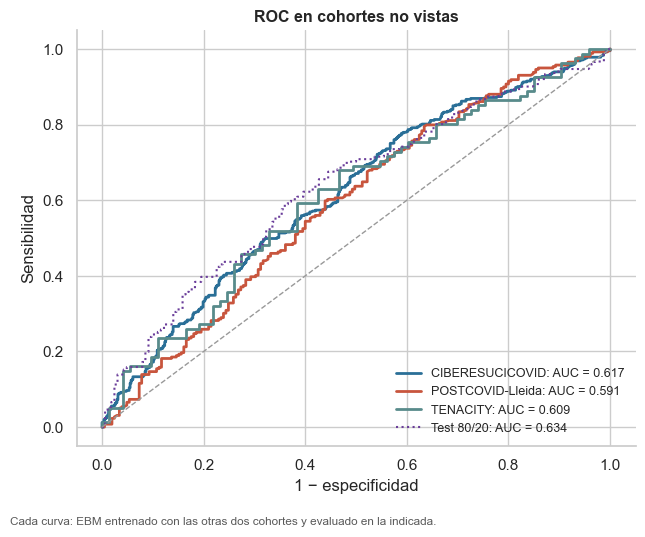

,N entrenamiento,N evaluación,ROC-AUC,IC95,PR-AUC,% F2,Brier
cohorte evaluada (no vista),,,,,,,
CIBERESUCICOVID,618,956,0.617,0.580–0.650,0.541,43.2,0.255
POSTCOVID-Lleida,1110,464,0.591,0.536–0.642,0.615,55.8,0.266
TENACITY,1420,154,0.609,0.522–0.695,0.628,52.6,0.251


In [14]:
filas = []
curvas = {}
for c in ["CIBERESUCICOVID", "POSTCOVID_LLEIDA", "TENACITY"]:
    tr, te = dataset[dataset["cohorte_analisis"] != c], dataset[dataset["cohorte_analisis"] == c]
    m = ExplainableBoostingClassifier(**ebm.get_params()).fit(tr[FEATS], tr["y"])
    p = m.predict_proba(te[FEATS])[:, 1]
    y = te["y"].to_numpy()
    lo, hi = ic_bootstrap(y, p, roc_auc_score, MC["n_bootstrap_ic"], SEMILLA)
    curvas[c] = roc_curve(y, p)[:2]
    filas.append({"cohorte evaluada (no vista)": ETQ[c], "N entrenamiento": len(tr), "N evaluación": len(te),
                  "ROC-AUC": round(roc_auc_score(y, p), 3), "IC95": f"{lo:.3f}–{hi:.3f}",
                  "PR-AUC": round(average_precision_score(y, p), 3), "% F2": round(100 * y.mean(), 1),
                  "Brier": round(brier_score_loss(y, p), 3)})
loco = pd.DataFrame(filas).set_index("cohorte evaluada (no vista)")
loco.to_csv(TAB / f"{PFX}_validacion_loco.csv")

fig, ax = plt.subplots(figsize=(6.5, 5.2))
for c, (f, t) in curvas.items():
    ax.plot(f, t, color=COLOR[c], lw=2, label=f"{ETQ[c]}: AUC = {loco.loc[ETQ[c], 'ROC-AUC']:.3f}")
f, t, _ = roc_curve(y_te, p_ebm)
ax.plot(f, t, color=C_EBM, lw=1.5, ls=":", label=f"Test 80/20: AUC = {roc_auc_score(y_te, p_ebm):.3f}")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1)
ax.set_xlabel("1 − especificidad"); ax.set_ylabel("Sensibilidad"); ax.set_title("ROC en cohortes no vistas")
ax.legend(frameon=False, fontsize=9, loc="lower right")
nota(fig, "Cada curva: EBM entrenado con las otras dos cohortes y evaluado en la indicada.")
plt.tight_layout(); guardar(fig, "roc_loco"); plt.show()
loco

## 8 · Guardar el modelo

In [15]:
with open(DATOS / "modelo_ebm_h3.pkl", "wb") as f:
    pickle.dump({"modelo": ebm, "predictores": FEATS, "umbral_youden": UMBRAL_YOUDEN,
                 "clase_positiva": MC["clase_positiva"], "semilla": SEMILLA}, f)
print(f"Modelo guardado en {DATOS.name}/modelo_ebm_h3.pkl (fuera del repositorio)")

Modelo guardado en Datos limpios/modelo_ebm_h3.pkl (fuera del repositorio)


## 9 · Resumen

**Resultados (ejecución con semilla 2026).**

1. **Capacidad predictiva modesta.** En el test 80/20 (315 pacientes):
   - **ROC-AUC 0,634** [0,574–0,696] y PR-AUC 0,616, frente a una prevalencia de 0,48.
   - En la validación cruzada de entrenamiento, el AUC es de 0,62: el test no es casualidad.
   - Con el umbral de Youden (0,47): sensibilidad 56 %, especificidad 65 % y exactitud 61 %.
   - Supera claramente al azar, pero **no sirve para decidir sobre un paciente individual**.
2. **El EBM no supera a la regresión logística** (AUC 0,633). Con estos predictores apenas hay no linealidad aprovechable; la ventaja del EBM es que muestra la forma de cada efecto.
3. **Calibración aceptable** (Brier 0,236): las probabilidades predichas se concentran entre 0,3 y 0,7, así que el modelo rara vez está "seguro".
4. **Se mantiene en cohortes no vistas (§7):** AUC de 0,62 en CIBERESUCICOVID, 0,59 en Lleida y 0,61 en TENACITY. Es algo menor que en el test 80/20, como era de esperar, pero **transferible**: no depende de la cohorte con la que aprendió.
5. **Qué aprende (§5)**, de mayor a menor importancia:
   - **Estancia hospitalaria:** el riesgo de afectación funcional sube de forma casi lineal con los días de ingreso (estancia > 35 días → log-odds > 0). Es el predictor principal y tiene sentido clínico como marcador de gravedad.
   - **Comorbilidad:** EPOC, enfermedad renal, diabetes, hipertensión y tabaquismo activo aumentan el riesgo. También tiene sentido.
   - **Edad:** a menor edad, *más* riesgo. Es contraintuitivo; probablemente es un sesgo de selección (los mayores con seguimiento y espirometría son los más sanos) o un efecto de los valores de referencia del % del predicho. **No debe interpretarse como causal.**
   - **UCI = 0 → más riesgo.** Los pacientes sin UCI son casi todos de **Lleida** (CIBERESUCICOVID y TENACITY son ~100 % UCI), que tiene más F2. Es en buena parte un **indicador de cohorte**, no un efecto de la UCI.

**Implicaciones**
- **Los datos del alta comunes dicen poco sobre la función a 3 meses.** El fenotipo se define con espirometría y DLCO, que al alta no se tienen. Es el límite de usar solo variables comunes.
- **Para mejorar el modelo** harían falta predictores de la fase aguda más ricos (ventilación mecánica, PaO2/FiO2, analítica, días de UCI), pero solo están en algunas cohortes. La alternativa es un **modelo extendido solo para CIBERESUCICOVID**, validado dejando fuera cada centro.
- **Uso razonable:** **estratificación de riesgo** (priorizar el seguimiento de pacientes con estancia larga y comorbilidad respiratoria o renal), no diagnóstico individual.

**Limitaciones:**
- **Predictores pobres.** Solo se usan las variables del alta comunes a las tres cohortes. Las más informativas de la fase aguda (ventilación, analítica, PaO2/FiO2) existen solo en algunas cohortes.
- **La diana es un fenotipo derivado** de un clustering, con su propia incertidumbre (Jaccard 0,92; notebook 05).
- **Sesgo de seguimiento.** Solo entran pacientes con función pulmonar medida a los 3 meses.
- **Validación optimista.** La partición 80/20 mezcla cohortes; la validación en cohortes no vistas (§7) es la estimación realista.